<a href="https://colab.research.google.com/github/xRomory/CCMACLRL_COM231ML_PROJECT/blob/labli/us_fake_news_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fake News Detection using Naive Bayes and Support Vector Machine


Import Python Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report


## Datasets

In [2]:
fake_url = "https://github.com/xRomory/CCMACLRL_COM231ML_PROJECT/blob/main/fake_news/datasets/fake_compressed.csv?raw=true"
fake_data = pd.read_csv(fake_url)

fake_data.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
true_url = "https://github.com/xRomory/CCMACLRL_COM231ML_PROJECT/blob/main/fake_news/datasets/true_compressed.csv?raw=true"
true_data = pd.read_csv(true_url)

true_data.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
# Combine Both .csv file and add a label to classify real news and fake news dataset

fake_data["Label"], true_data["Label"] = "F", "R"

data = pd.concat([fake_data, true_data], axis=0)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,title,text,subject,date,Label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",F
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",R
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",R
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",F
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",R


### Find out what's in the data

In [5]:
data.shape

(44898, 5)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   Label    44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


In [7]:
data.describe(include=["object"]).T

,count,unique,top,freq
title,44898,38729,Factbox: Trump fills top jobs for his administ...,14
text,44898,38646,,627
subject,44898,8,politicsNews,11272
date,44898,2397,"December 20, 2017",182
Label,44898,2,F,23481


Check for any missing and duplicated values

In [8]:
# Check for missing values
data.isna().sum()

,0
title,0
text,0
subject,0
date,0
Label,0


In [9]:
#Check for duplicate values
data.duplicated().sum()

np.int64(209)

In [10]:
#See all instances of duplicated rows
data[data.duplicated(keep=False)]

,title,text,subject,date,Label
308,Polish president signs judicial overhaul bills...,WARSAW (Reuters) - Polish President Andrzej Du...,worldnews,"December 20, 2017",R
328,Denmark no longer to automatically accept U.N....,COPENHAGEN (Reuters) - Denmark will no longer ...,worldnews,"December 20, 2017",R
367,"Food security in Middle East, North Africa det...",CAIRO (Reuters) - Food security in the Middle ...,worldnews,"December 21, 2017",R
474,"Kenya police use teargas, shoot in air during ...",NAIROBI (Reuters) - Kenyan police fired tearga...,worldnews,"October 9, 2017",R
486,Turkish PM calls Rohingya killings in Myanmar ...,"COX S BAZAR, Bangladesh (Reuters) - Turkey s p...",worldnews,"December 20, 2017",R
...,...,...,...,...,...
44673,Kuwait says GCC to keep operating despite Qata...,DUBAI (Reuters) - Kuwait s deputy foreign mini...,worldnews,"December 27, 2017",R
44721,Syrian rebels say discussing evacuation from t...,BEIRUT (Reuters) - Syrian rebels in a pocket o...,worldnews,"December 27, 2017",R
44786,Russia may widen designation for media outlets...,MOSCOW (Reuters) - Russia may decide to design...,worldnews,"December 21, 2017",R
44849,Senate tax bill stalls on deficit-focused 'tri...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,"November 30, 2017",R


In [11]:
# Get value counts of Label
data.Label.value_counts()

,count
Label,
F,23481
R,21417


### Data Visualization

See the ratio of news subjects inside the datasets

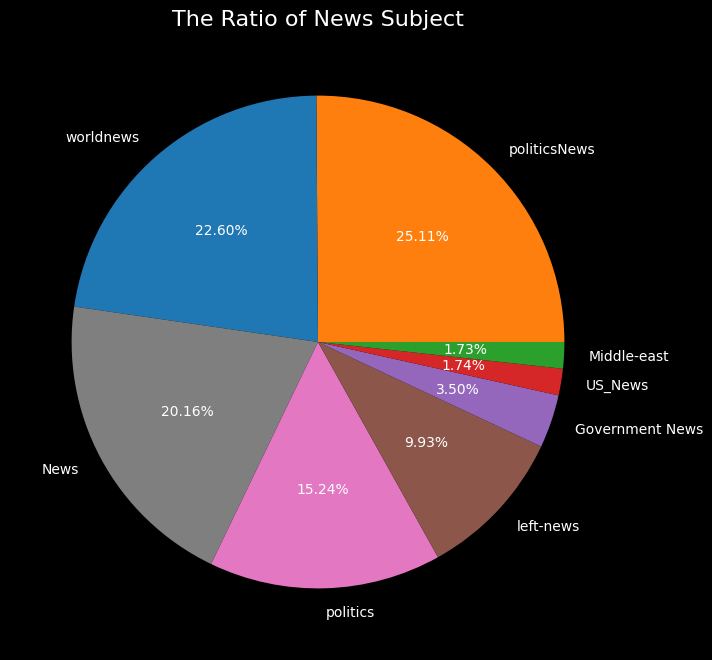

In [12]:
# Color of Pie chart
color_map = {
    "worldnews": "#1f77b4",
    "politicsNews": "#ff7f0e",
    "Middle-east": "#2ca02c",
    "US_News": "#d62728",
    "Government News": "#9467bd",
    "left-news": "#8c564b",
    "politics": "#e377c2",
    "News": "#7f7f7f"
}

subject_count = data["subject"].value_counts()
labels = subject_count.index.to_list()

colors = [color_map[label] for label in labels]
plt.style.use("dark_background")
plt.figure(figsize=(8, 8))
plt.pie(
    x=subject_count,
    autopct="%1.2f%%",
    labels=labels,
    colors=colors,
)
plt.title("The Ratio of News Subject", fontsize=16)
plt.show()

See target distribution of our data:

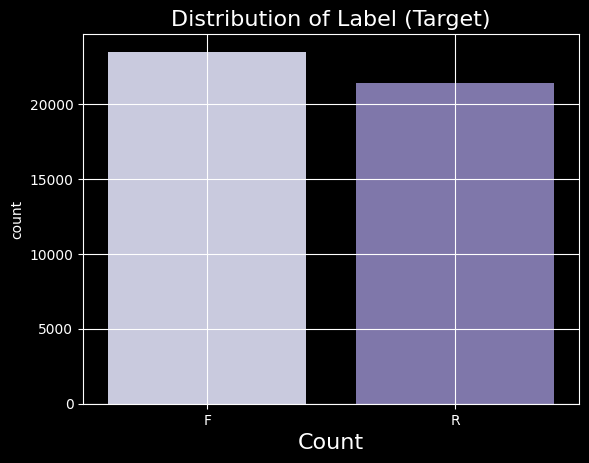

In [13]:
sns.countplot(x=data.Label, data=data, palette="Purples", hue="Label")
plt.title("Distribution of Label (Target)", fontsize=16)
plt.xlabel("Target", fontsize=16)
plt.xlabel("Count", fontsize=16)
plt.grid(True)
plt.show()

See subject counts inside our datasets (Fake, and Real).

In [14]:
data_counts = data.groupby(["subject", "Label"]).size().unstack(fill_value=0)
data_counts

Label,F,R
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6841,0
politicsNews,0,11272
worldnews,0,10145


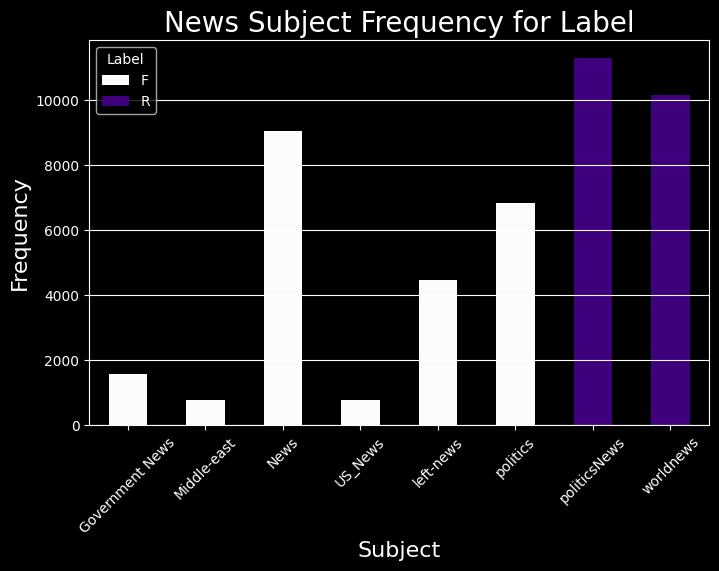

In [15]:
plt.figure(figsize=(8, 5))
data_counts.plot(
    kind="bar",
    stacked=True,
    colormap="Purples",
    ax=plt.gca()
)
plt.title("News Subject Frequency for Label", fontsize=20)
plt.xlabel("Subject", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.grid(True, axis='y')
plt.xticks(rotation=45)
plt.show()

See frequent word used in our datasets

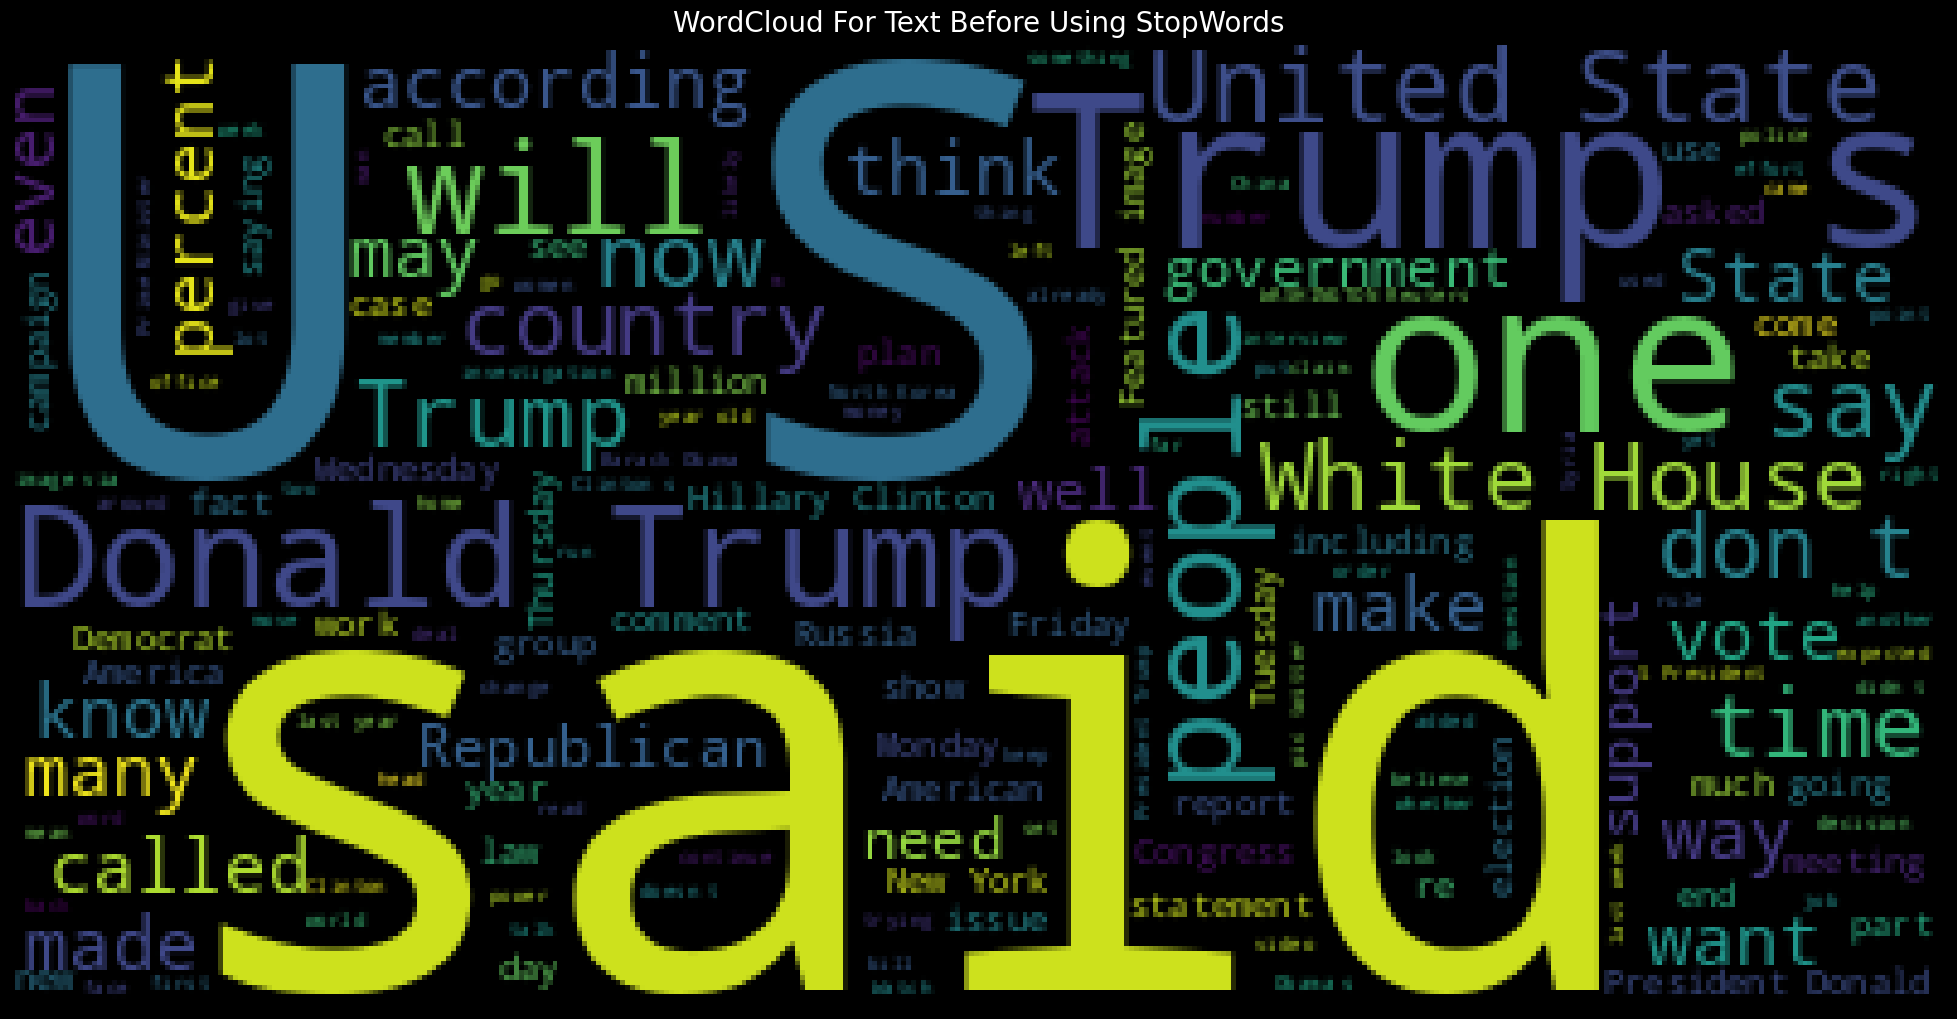

In [16]:
plt.figure(figsize=(25, 15))
plt.imshow(WordCloud(background_color='black').generate(" ".join(data.text)))
plt.axis("off")
plt.title("WordCloud For Text Before Using StopWords", fontsize=20)
plt.show()

### Data pre-processing

A while ago, we noticed that we have duplicated values. So, what we can do is drop them.

In [17]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44689 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44689 non-null  object
 1   text     44689 non-null  object
 2   subject  44689 non-null  object
 3   date     44689 non-null  object
 4   Label    44689 non-null  object
dtypes: object(5)
memory usage: 2.0+ MB


Use stopwords to exclude common, rarely, always, and frequent words in the combined documents

In [60]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(
    stop_words=ENGLISH_STOP_WORDS,  # remove common words
    ngram_range=(1,2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

See data text in our datasets

In [61]:
data_text = data.text
data_text

,text
0,"21st Century Wire says Ben Stein, reputable pr..."
1,WASHINGTON (Reuters) - U.S. President Donald T...
2,(Reuters) - Puerto Rico Governor Ricardo Rosse...
3,"On Monday, Donald Trump once again embarrassed..."
4,"GLASGOW, Scotland (Reuters) - Most U.S. presid..."
...,...
44893,
44894,LONDON/TOKYO (Reuters) - British Prime Ministe...
44895,BERLIN (Reuters) - Chancellor Angela Merkel sa...
44896,Jesus f*cking Christ our President* is a moron...


In [62]:
import re
def normalize_text(text):
    # Remove X user handle starting with "@"
    text=re.sub(r'@\w+', '', text)

    # Remove non-alphanumeric characters and extra whitespaces
    text=re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove multiple whitespaces
    text=re.sub(r'\s+', ' ', text)

    # Convert data text to lowercase
    text = text.lower()

    return text

In [63]:
data_text = data_text.apply(normalize_text)
data_text

,text
0,st century wire says ben stein reputable profe...
1,washington reuters us president donald trump r...
2,reuters puerto rico governor ricardo rossello ...
3,on monday donald trump once again embarrassed ...
4,glasgow scotland reuters most us presidential ...
...,...
44893,
44894,londontokyo reuters british prime minister the...
44895,berlin reuters chancellor angela merkel said g...
44896,jesus fcking christ our president is a moron n...


In [64]:
data_target = data.Label
data_target

,Label
0,0
1,1
2,1
3,0
4,1
...,...
44893,0
44894,1
44895,1
44896,0


In [65]:
# Transform "R" and "F" to a numeric for easy data modeling
data_target.replace('R', 1, inplace=True)
data_target.replace('F', 0, inplace=True)
data_target

,Label
0,0
1,1
2,1
3,0
4,1
...,...
44893,0
44894,1
44895,1
44896,0


In [66]:
x_train, x_test, y_train, y_test = train_test_split(
    data_text,
    data_target,
    test_size=0.2,
    random_state=42
)

print("x_train Shape:", x_train.shape)
print("x_test Shape:", x_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

x_train Shape: (35751,)
x_test Shape: (8938,)
y_train Shape: (35751,)
y_test Shape: (8938,)


#### Naive Bayes

In [69]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

nb_model = make_pipeline(TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=3, max_df=0.9, sublinear_tf=True), MultinomialNB(alpha=0.1))
nb_model.fit(x_train, y_train)
y_pred = nb_model.predict(x_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.9750503468337436
Precision: 0.9692769692769693
Recall: 0.9790013999066729
F1 Score: 0.9741149158444573


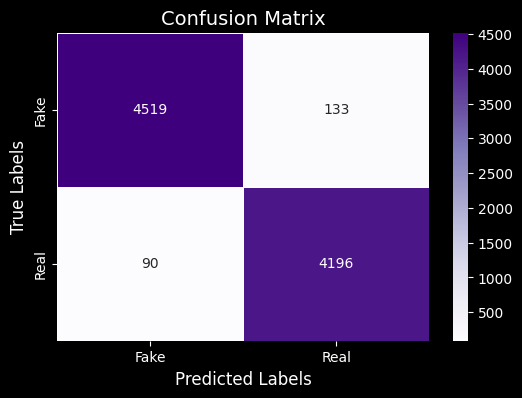

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, y_pred)
target_names = ['Fake', 'Real']

plt.style.use('dark_background')
plt.figure(figsize=(6,4))

sns.heatmap(
    c_matrix,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=target_names,
    yticklabels=target_names,
    cbar=True,
    linecolor='white',
    linewidths=0.5
)

plt.xlabel("Predicted Labels", fontsize=12, color='white')
plt.ylabel("True Labels", fontsize=12, color='white')
plt.title("Confusion Matrix", fontsize=14, color='white')

plt.show()


Receiver Operating Characteristic Curve to visualize false and true positives and overall probability of counting fake.

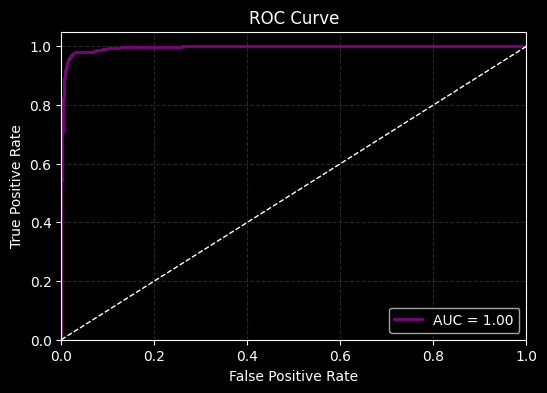

In [72]:
from sklearn.metrics import roc_curve, auc

y_prob = nb_model.predict_proba(x_test)[:,1] #Real
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1], color='white', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', color='white')
plt.ylabel('True Positive Rate', color='white')
plt.title('ROC Curve', color='white')
plt.legend(loc="lower right")
plt.grid(True, color='gray', linestyle='--', alpha=0.3)
plt.show()

#### Support Vector Machine

In [74]:
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

base_svm = LinearSVC(C=1.0, random_state=42, max_iter=10000)

svm_model = make_pipeline(TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=3, max_df=0.9, sublinear_tf=True), CalibratedClassifierCV(base_svm))
svm_model.fit(x_train, y_train)

y_pred = svm_model.predict(x_test)
y_prob_svm = svm_model.predict_proba(x_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))

Accuracy: 0.9975385992392034
Precision: 0.9962756052141527
Recall: 0.9986000933271115
F1 Score: 0.9974364949895129


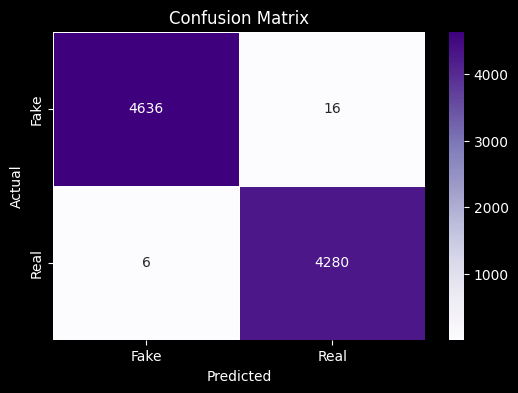

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
labels = ['Fake', 'Real']

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    linecolor='white',
    linewidths=0.5
)
plt.xlabel("Predicted", color='white')
plt.ylabel("Actual", color='white')
plt.title("Confusion Matrix", color='white')
plt.show()


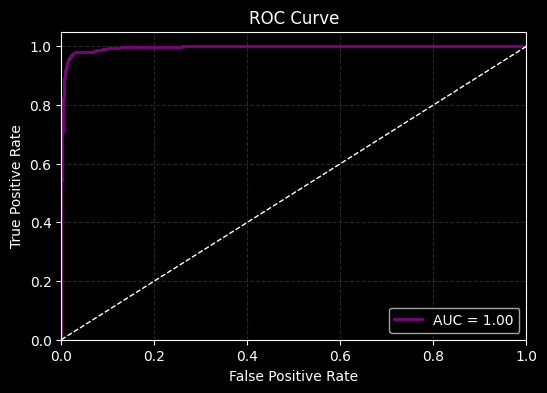

In [76]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], color='white', lw=1, linestyle='--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('False Positive Rate', color='white')
plt.ylabel('True Positive Rate', color='white')
plt.title('ROC Curve', color='white')
plt.legend(loc="lower right")
plt.grid(True, color='gray', linestyle='--', alpha=0.3)
plt.show()
